In [19]:
import pandas as pd

import protfasta
import numpy as np
import requests
import re
import warnings
warnings.filterwarnings("ignore")
import glob


from Bio import AlignIO
import matplotlib.pyplot as plt
from Bio.Align import AlignInfo

from Bio.Align import MultipleSeqAlignment
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq


import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import metapredict

In [20]:
import os
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import protfasta
import statsmodels.api as sm
import matplotlib.patches as patches



In [ ]:
# CONSERVATION
percent_identities_df = pd.read_csv("../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/KLF1")

In [10]:
# DISORDER
ref_seq = protfasta.read_fasta("../data/zoonomia_toga_mca_all_TFs/lambert_fastas/KLF1", invalid_sequence_action = 'convert')['lambert_seq']
disord_pred = metapredict.predict_disorder(ref_seq)
disord_df = pd.DataFrame(disord_pred)
disord_df

,0
0,0.8595
1,0.8833
2,0.8959
3,0.9069
4,0.9033
...,...
357,0.1598
358,0.1470
359,0.1297
360,0.1195


In [15]:
# ANNOTATIONS
annots = pd.read_csv("../soto_analysis/outputs/all_TFs_table_proteins.txt", sep = "\t")
klf1_annots = annots[annots["uniprotID"] == "Q13351"]
klf1_annots

,Unnamed: 0,1,2,uniprotID,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length
291,291,NaN,NaN,Q13351,NaN,ENST00000264834,"279-303,309-333,339-361","22-47,59-85",NaN,NaN,1


In [17]:

def plot_rectangle(start, end, color, box_height, ax, y = 0, alpha = 0.7, name = ""):
    rectangle = patches.Rectangle((start, y), width=end - start, height=box_height, linewidth=1, edgecolor='none', facecolor=color, alpha=alpha)
    ax.add_patch(rectangle)
    ax.text(np.mean([start, end]), 0.5 * box_height, name, fontsize = 'small', va = 'center', ha = 'center')

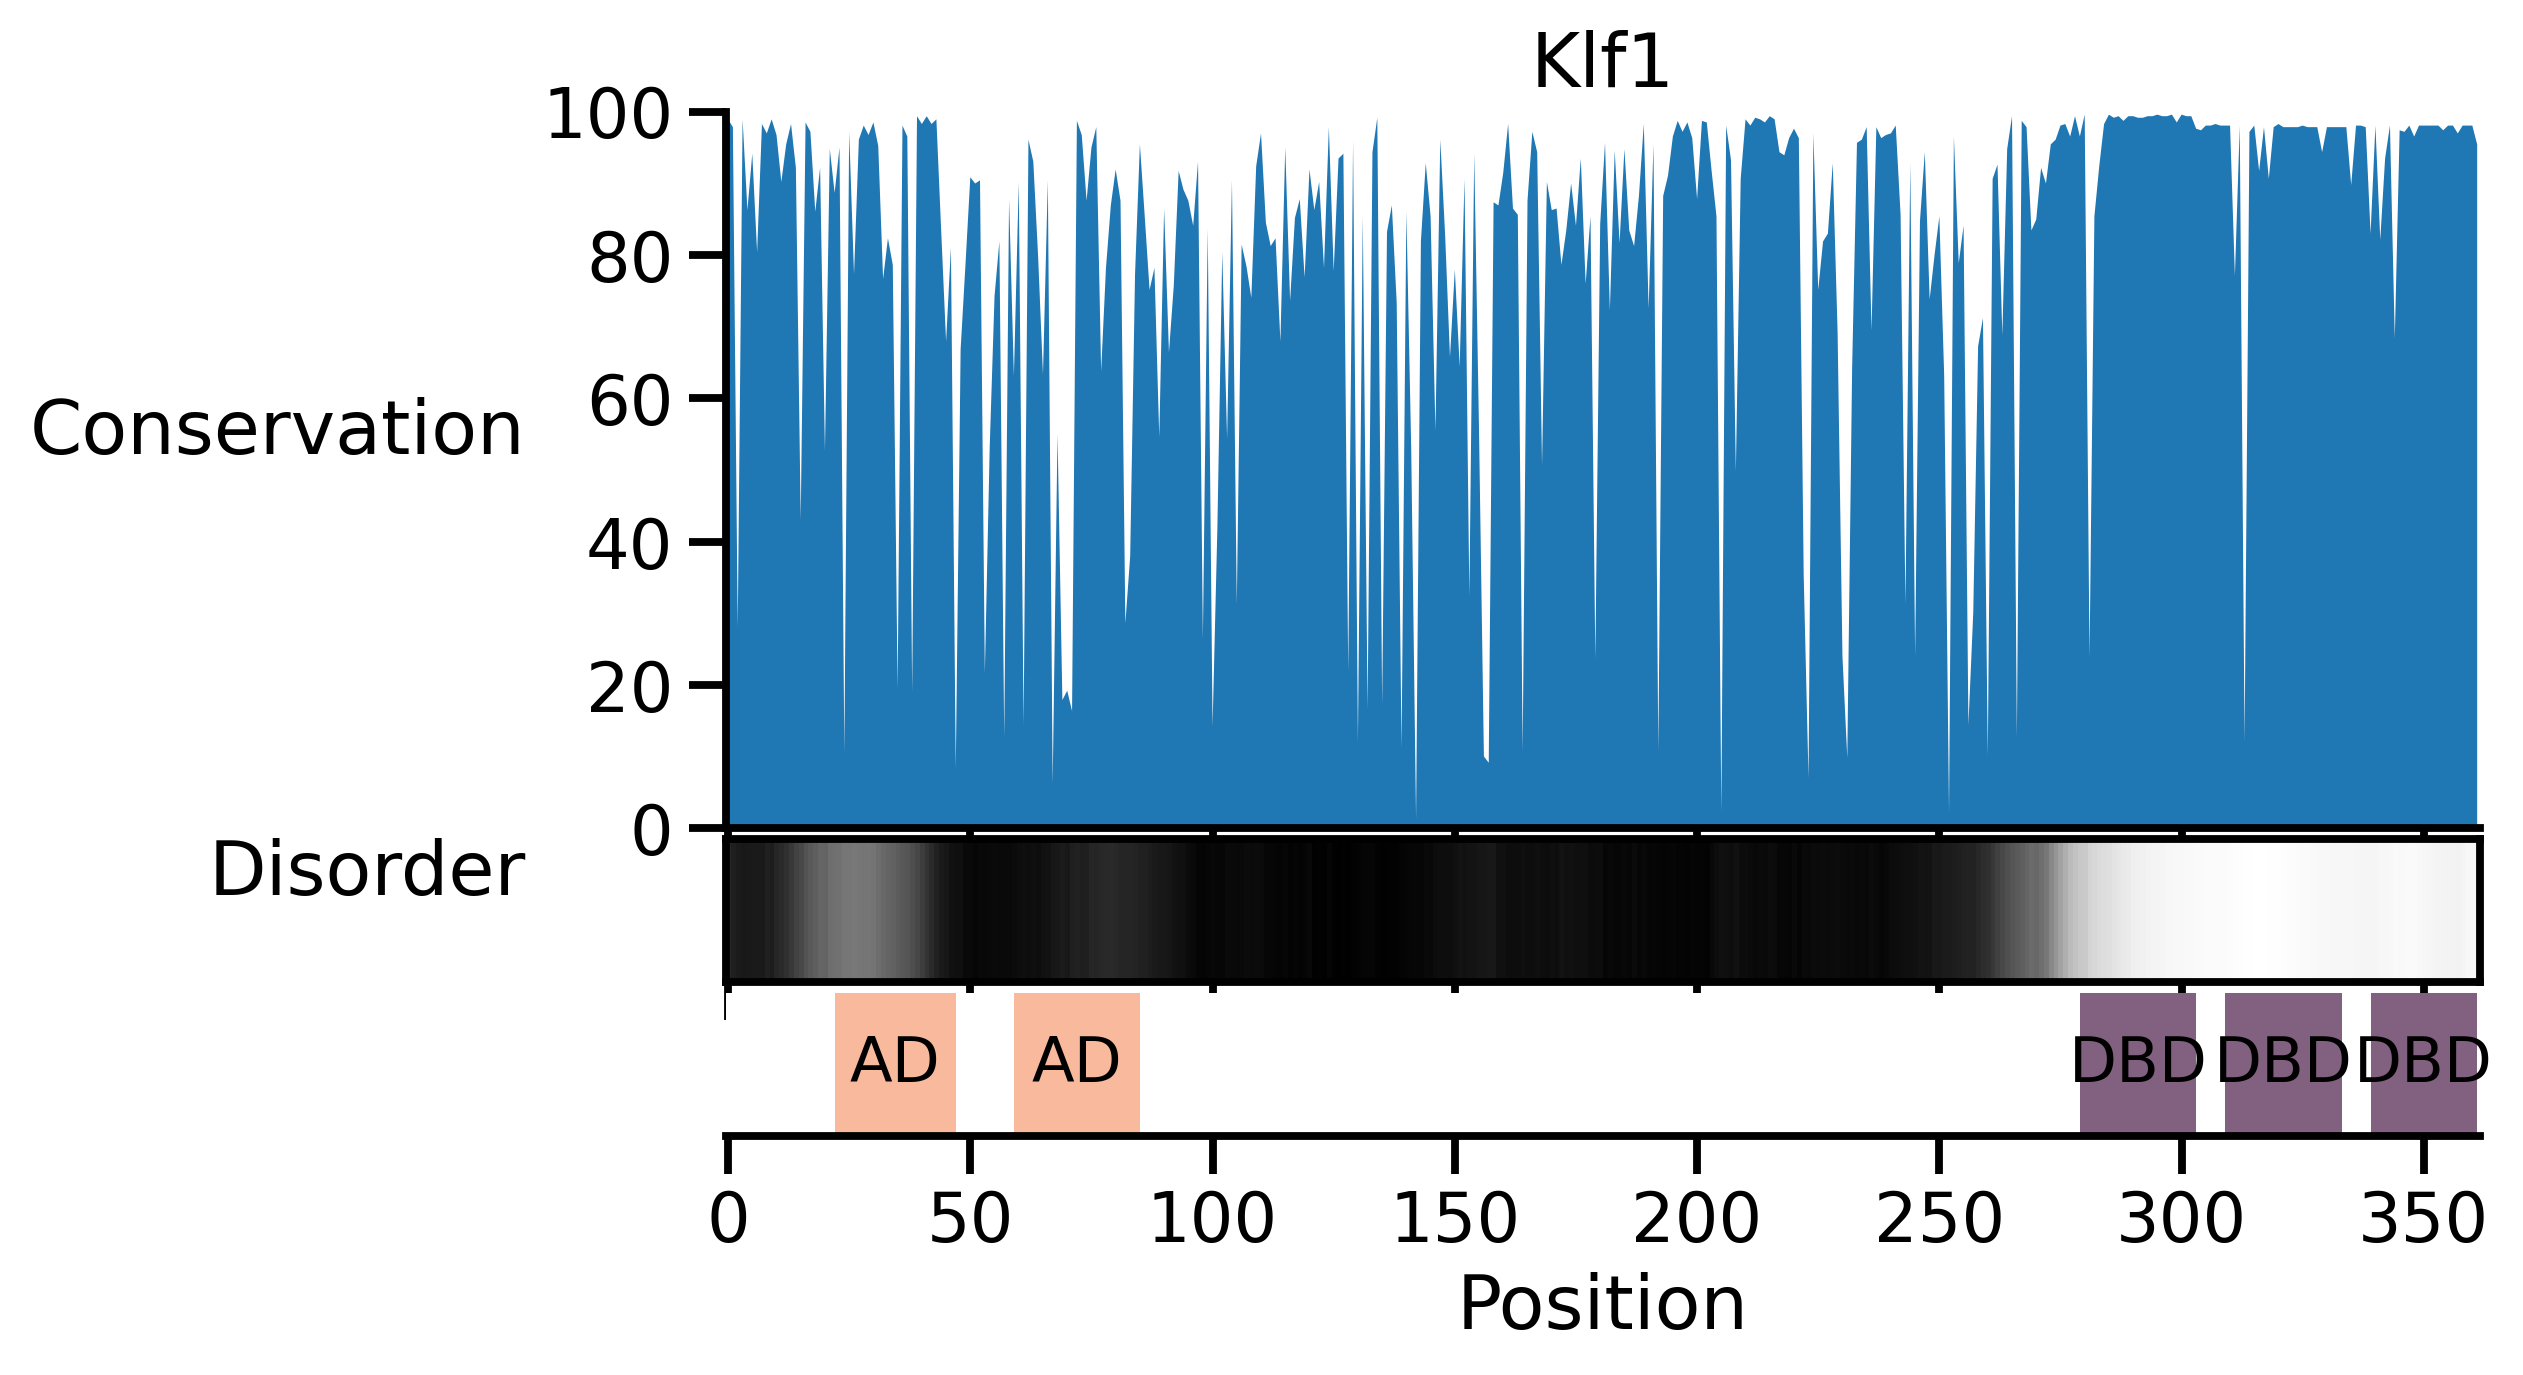

In [49]:

sns.set_context('talk')

fig, axs = plt.subplots(3, 1, figsize = (8, 4), dpi = 300, sharex = True, height_ratios=[1, 0.2, 0.2])

##CONSERVATION
# Fill the area under the line
axs[0].fill_between(x=percent_identities_df.index, 
                 y1=percent_identities_df["percent_identity"], alpha = 1)

axs[0].set_ylabel("Conservation", rotation = 0, ha = 'right')
axs[0].set_ylim(0, 100)

sns.despine(ax = axs[0])

## DISORDER
#sns.lineplot(disord_df[0], ax = axs[1])
axs[1].imshow(disord_df[[0]].T, cmap='Grays', aspect='auto')
axs[1].set_ylabel("Disorder", rotation = 0, ha = 'right')
axs[1].set_yticks([])

#sns.despine(ax = axs[1], left = True, bottom = True)
#axs[1].set_ylim(0, 1.01)

## LABELS DOMAINS
palette = sns.color_palette('rocket_r', 4)

plot_rectangle(279, 303, palette[-1], 1, axs[2], name = 'DBD')
plot_rectangle(309, 333, palette[-1], 1, axs[2], name = 'DBD')
plot_rectangle(339, 361, palette[-1], 1, axs[2], name = 'DBD')

plot_rectangle(22, 47, palette[0], 1, axs[2], name = 'AD')
plot_rectangle(59, 85, palette[0], 1, axs[2], name = 'AD')
sns.despine(ax = axs[2], left = True)
axs[2].set_yticks([])

# plot_rectangle(566, 645, palette[1], 1, axs[3], name = 'KIX')
# plot_rectangle(1728, 1809, palette[2], 1, axs[3], name = 'TAZ2')
# plot_rectangle(2039, 2141, palette[3], 1, axs[3], name = 'NCBD') # using https://www.pnas.org/doi/10.1073/pnas.0702010104 2039–2141

i = 0


#axs[-1].set_xlim(0, 2414)
axs[-1].set_xlabel("Position")

fig.align_ylabels(axs)
plt.tight_layout(pad = -0.4)

axs[0].set_title("Klf1")
plt.show()



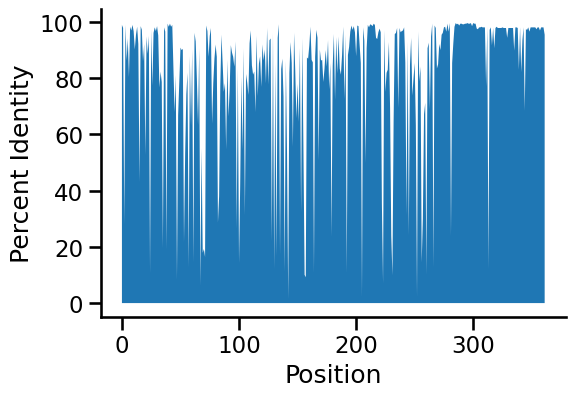

In [5]:
sns.set_context('talk')

plt.figure(figsize=(6, 4))

# Line plot
ax = sns.lineplot(data=percent_identities_df["percent_identity"], lw=0)

# Fill the area under the line
ax.fill_between(x=percent_identities_df.index, 
                 y1=percent_identities_df["percent_identity"], alpha=1)

ax.set_xlabel("Position")
ax.set_ylabel("Percent Identity")
# ax.set_ylim(0, 100)
# ax.set_xlim(0, 2414)
sns.despine()


plt.show()



NameError: name 'df' is not defined